# Exploration

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("Heart Attack Data Set.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [3]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000
mean,54.366337,0.683168,0.966997,131.623762,246.264026,0.148515,0.528053,149.646865,0.326733,1.039604,1.399340,0.729373,2.313531,0.544554
std,9.082101,0.466011,1.032052,17.538143,51.830751,0.356198,0.525860,22.905161,0.469794,1.161075,0.616226,1.022606,0.612277,0.498835
min,29.000000,0.000000,0.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,47.500000,0.000000,0.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,55.000000,1.000000,1.000000,130.000000,240.000000,0.000000,1.000000,153.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,274.500000,0.000000,1.000000,166.000000,1.000000,1.600000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [4]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [5]:
df.columns = df.columns.str.strip()

In [6]:
print("Dataset Shape:", df.shape)
print("\nColumns:\n", df.columns)

Dataset Shape: (303, 14)

Columns:
 Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'],
      dtype='object')


In [7]:
df['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

***binary classification***

0 = Tidak ada heart disease (sehat)

1 = Ada heart disease (sakit)

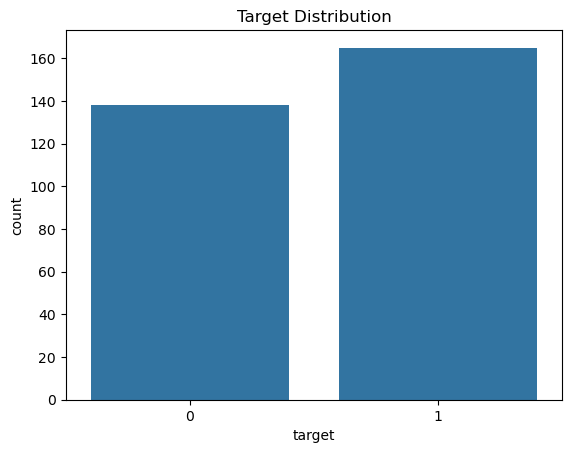

In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

# Target Distribution
sns.countplot(x='target', data=df)
plt.title("Target Distribution")
plt.show()

In [9]:
numeric = ['age','trestbps','chol','thalach','oldpeak']

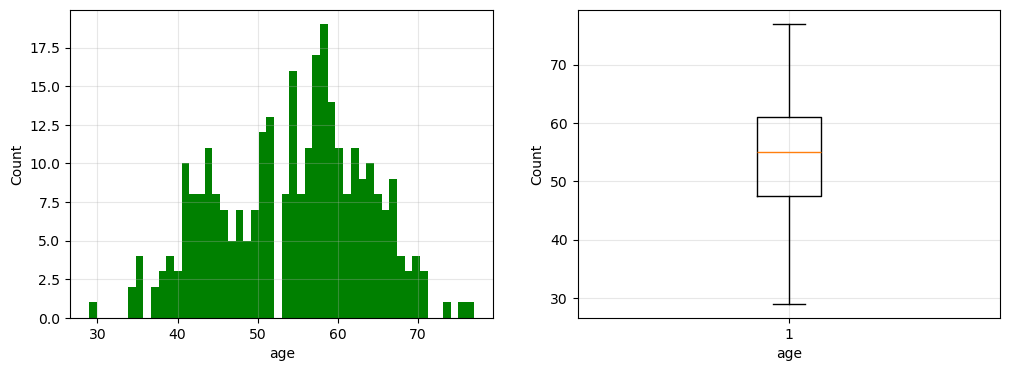

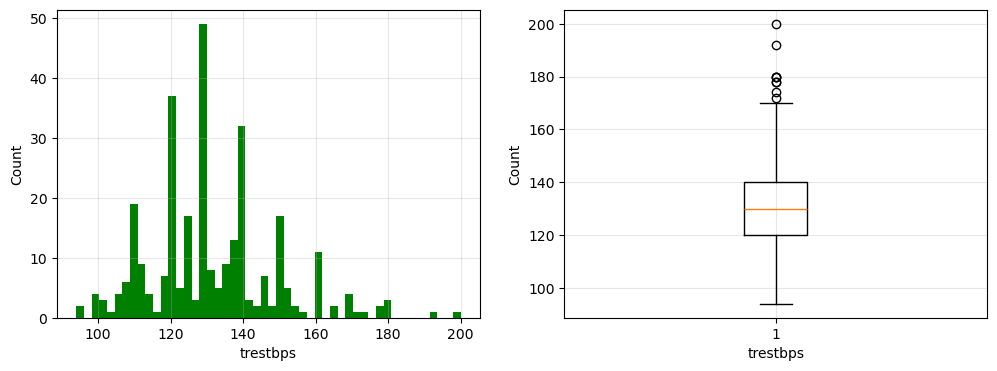

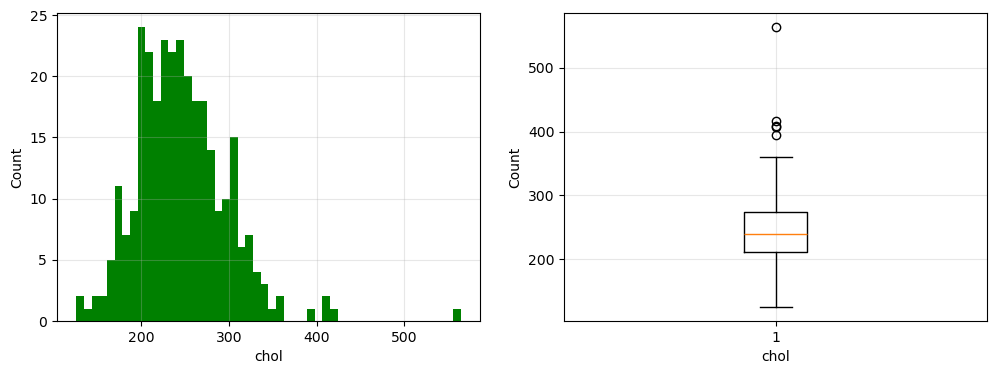

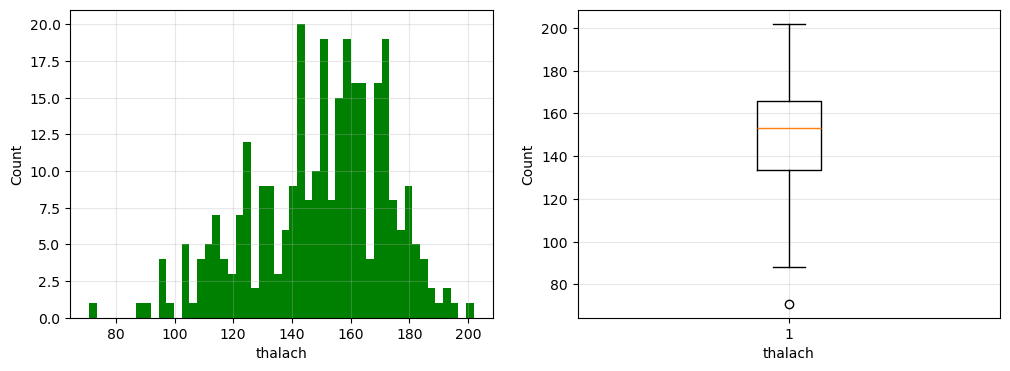

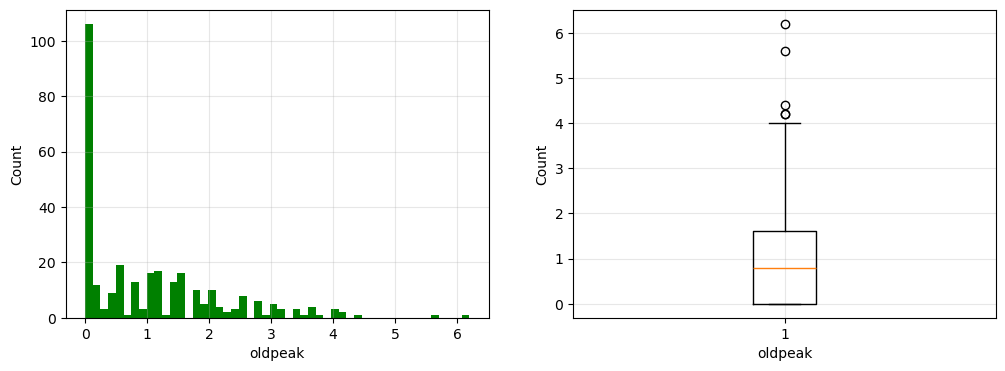

In [10]:
for col in df[numeric]:

    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)

    plt.hist(df[df[col]>=0][col], bins=50, color='green')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.grid(True, alpha=0.3)

    plt.subplot(1,2,2)

    plt.boxplot(x = df[df[col]>=0][col])
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.grid(True, alpha=0.3)

    plt.show()

In [11]:
kat = ['sex', 'cp', 'fbs', 'restecg', 'exang','slope', 'thal']

In [12]:
df[kat]=df[kat].astype(str)

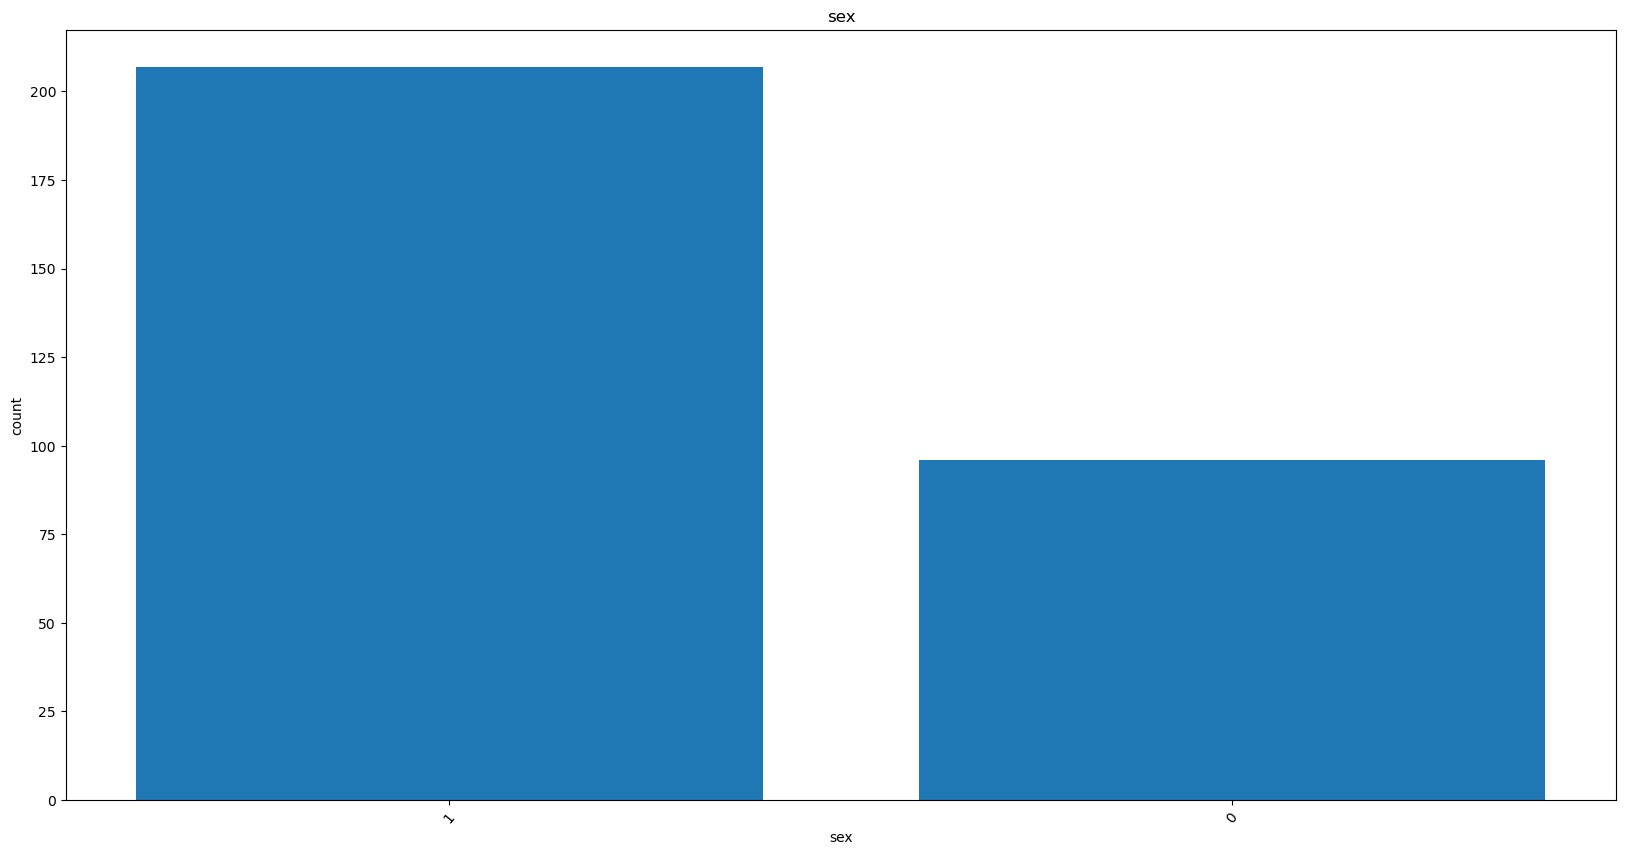

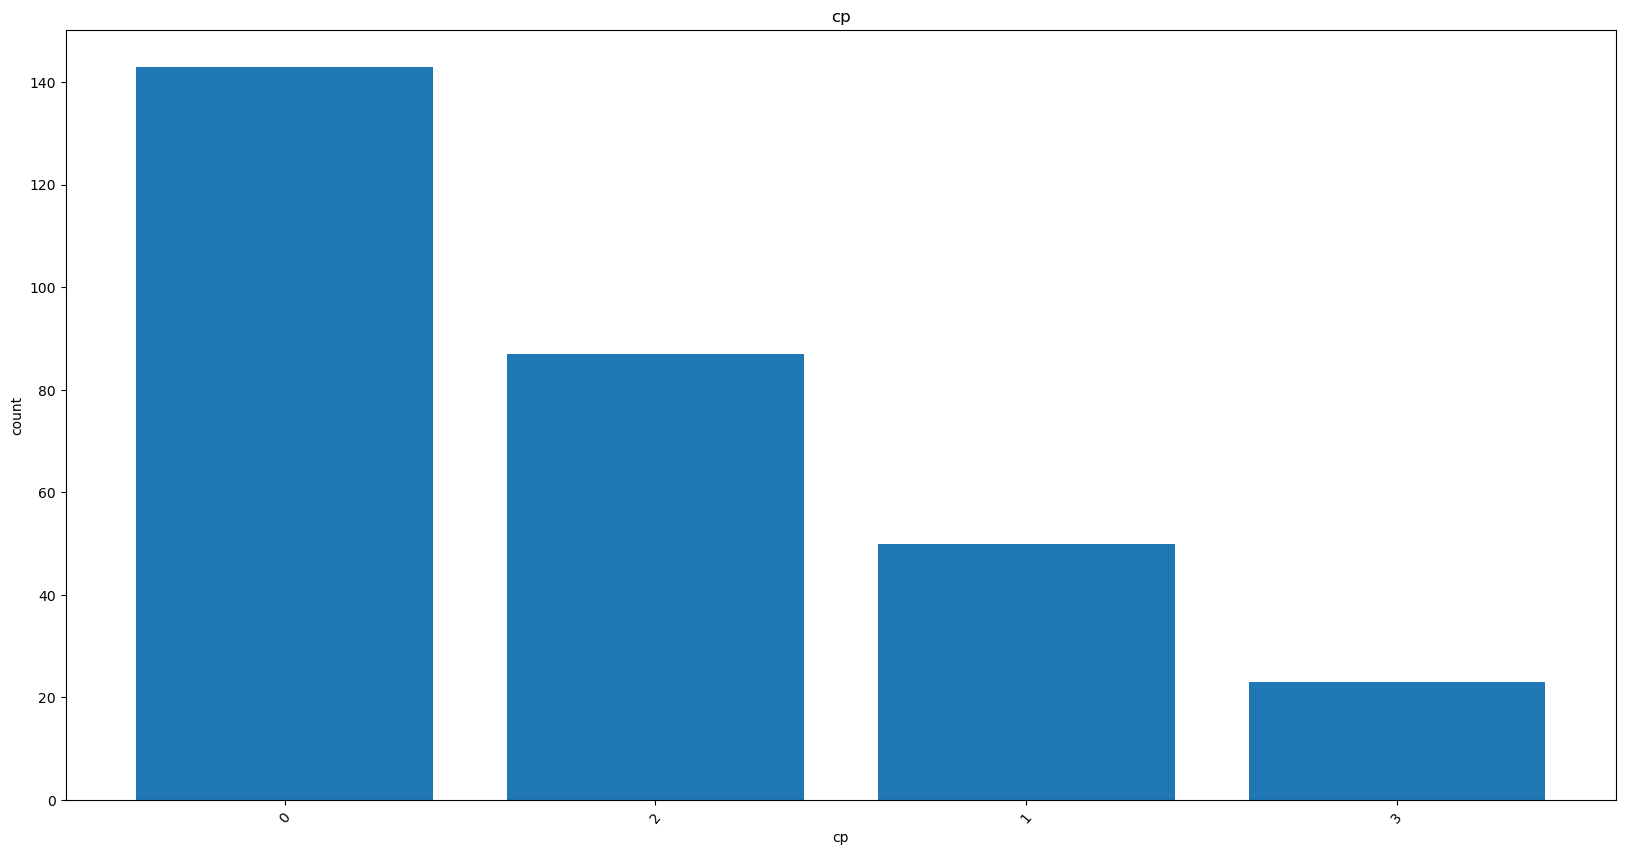

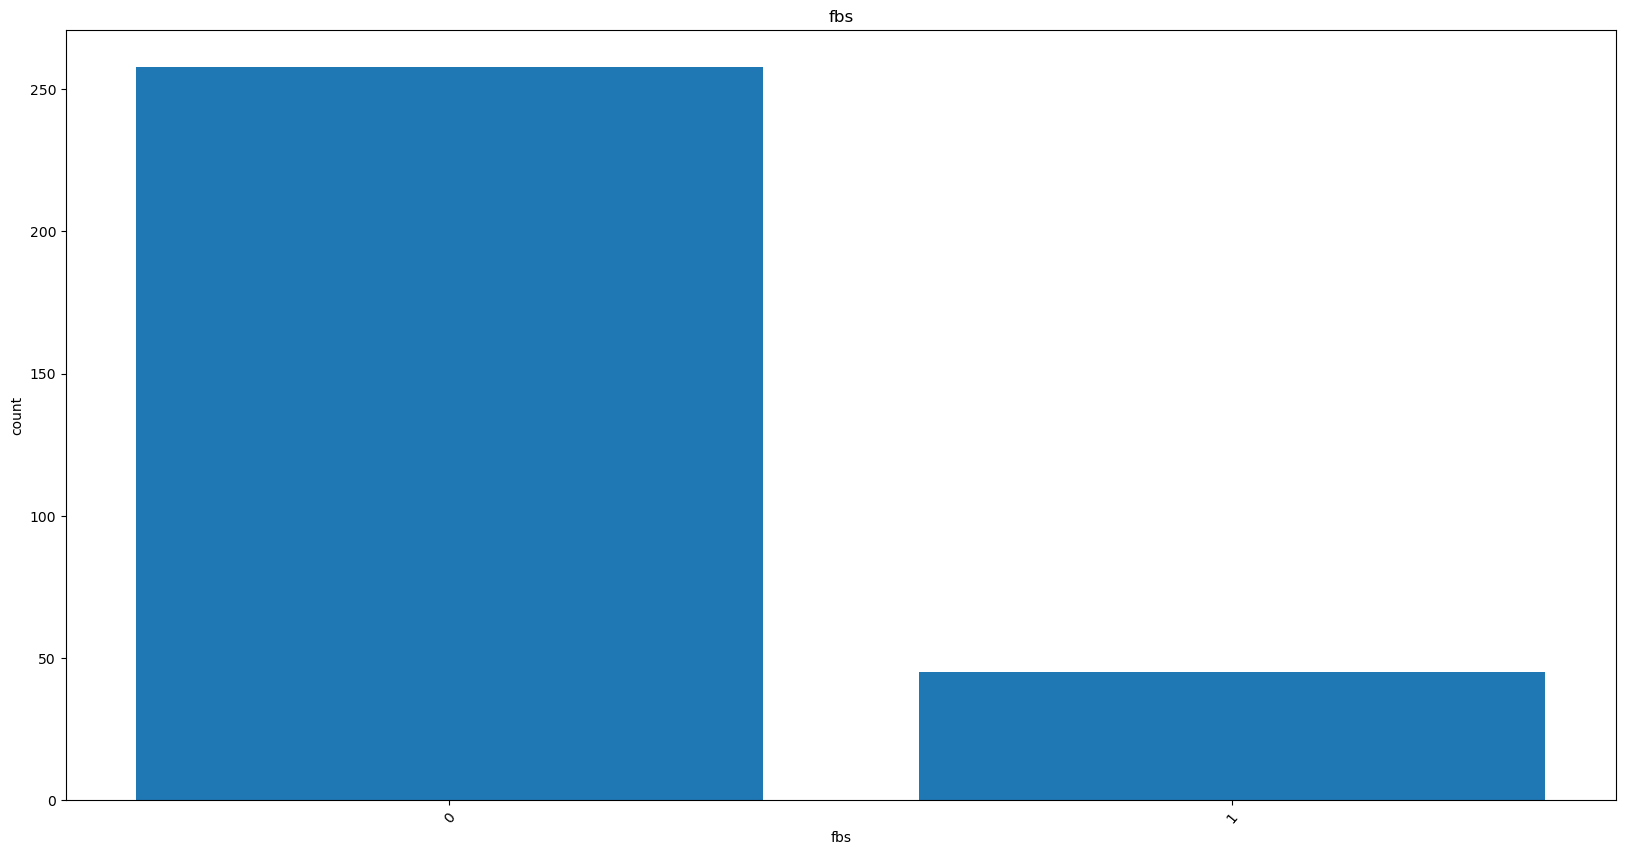

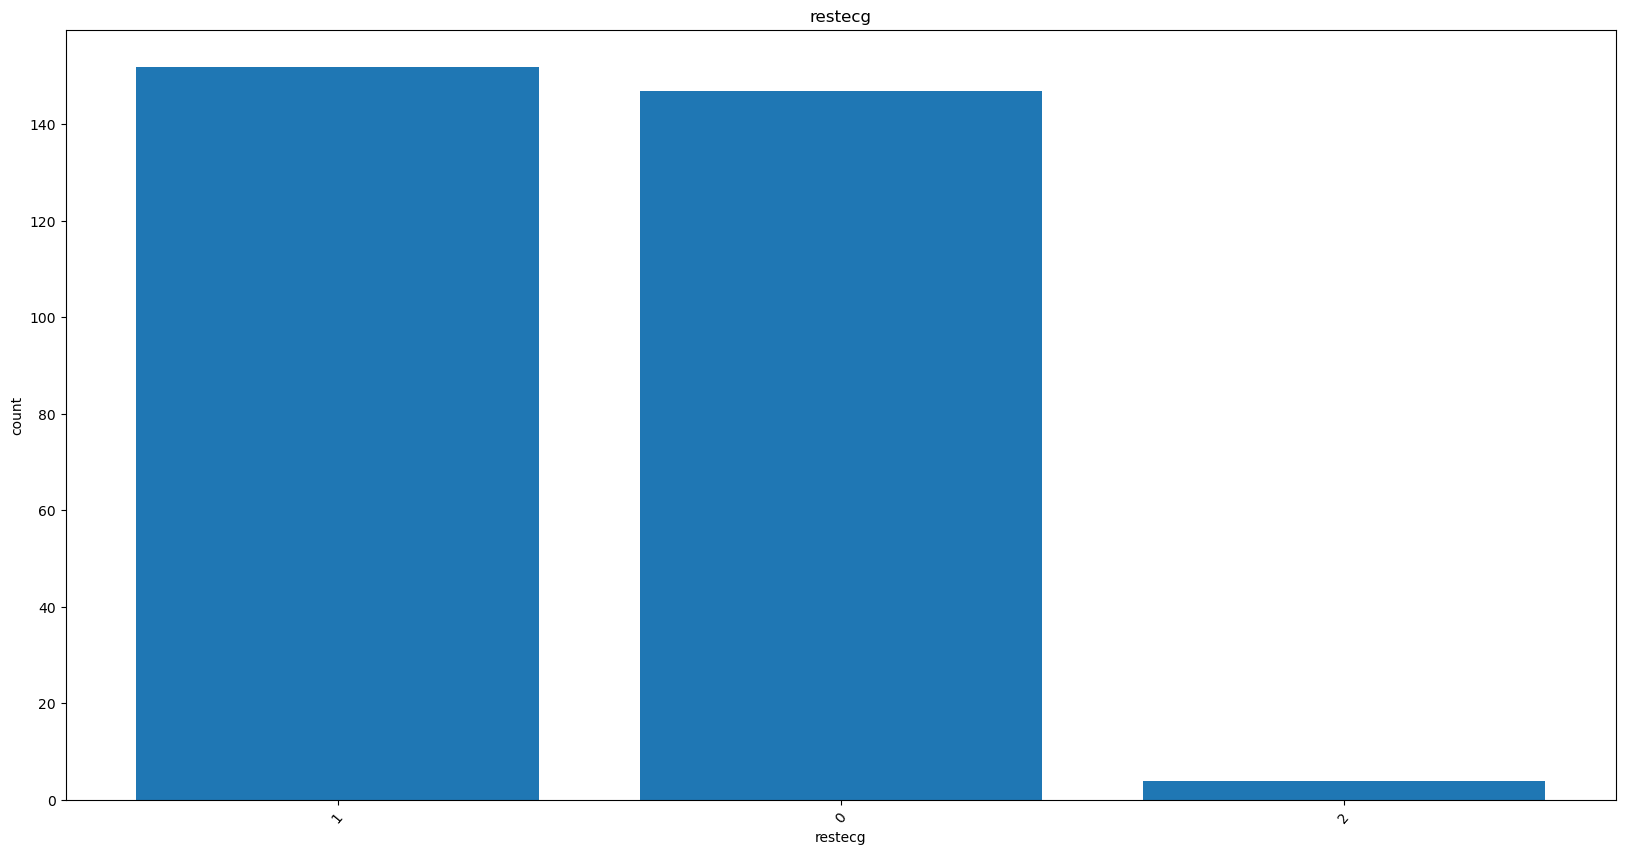

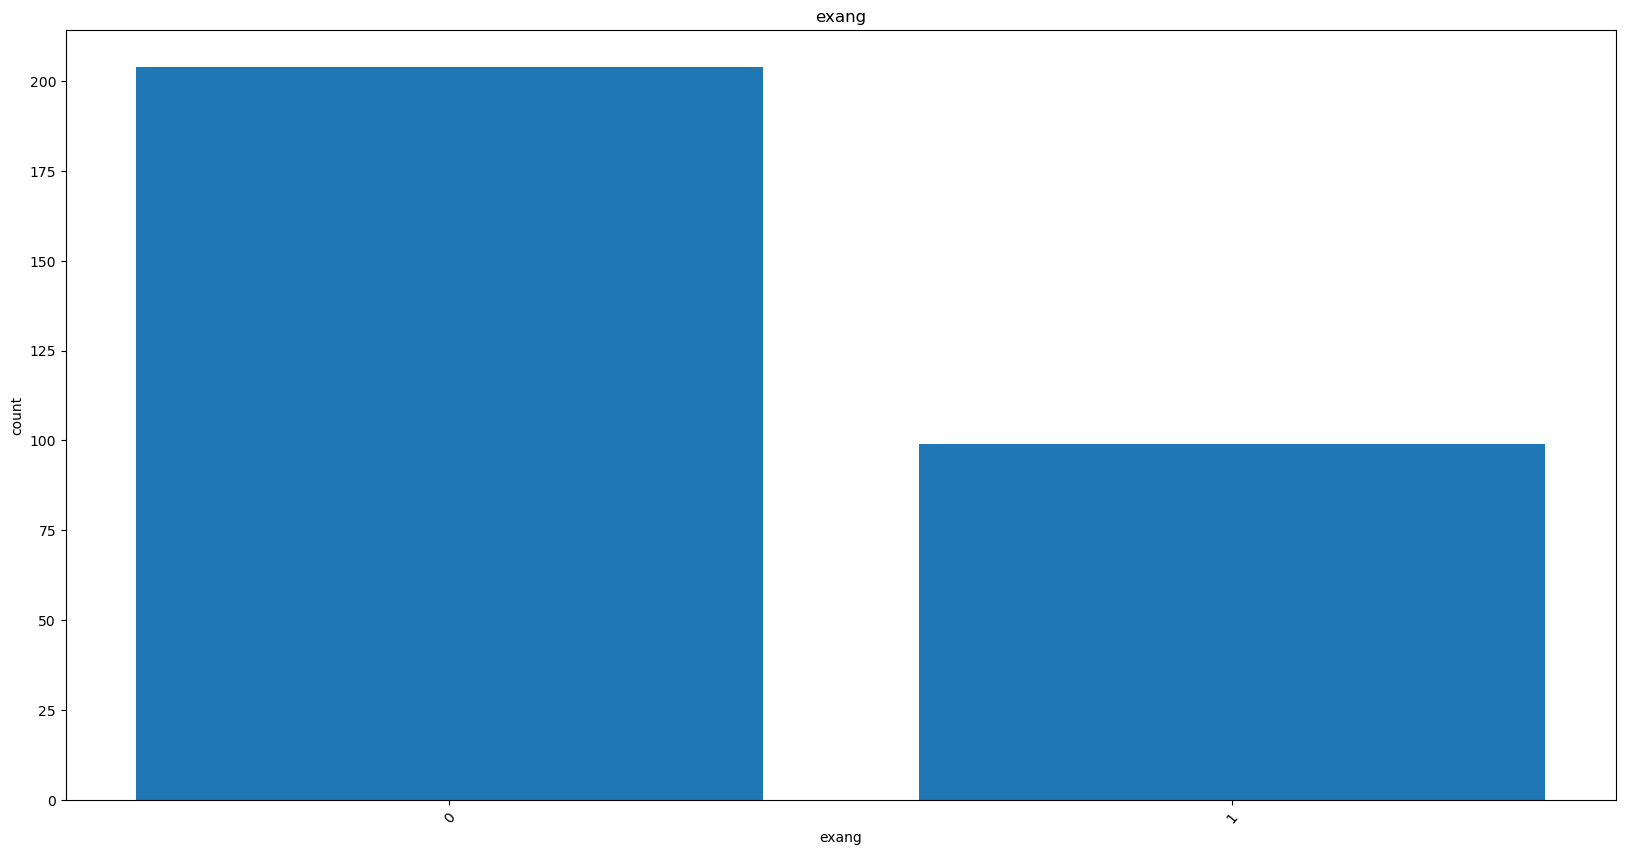

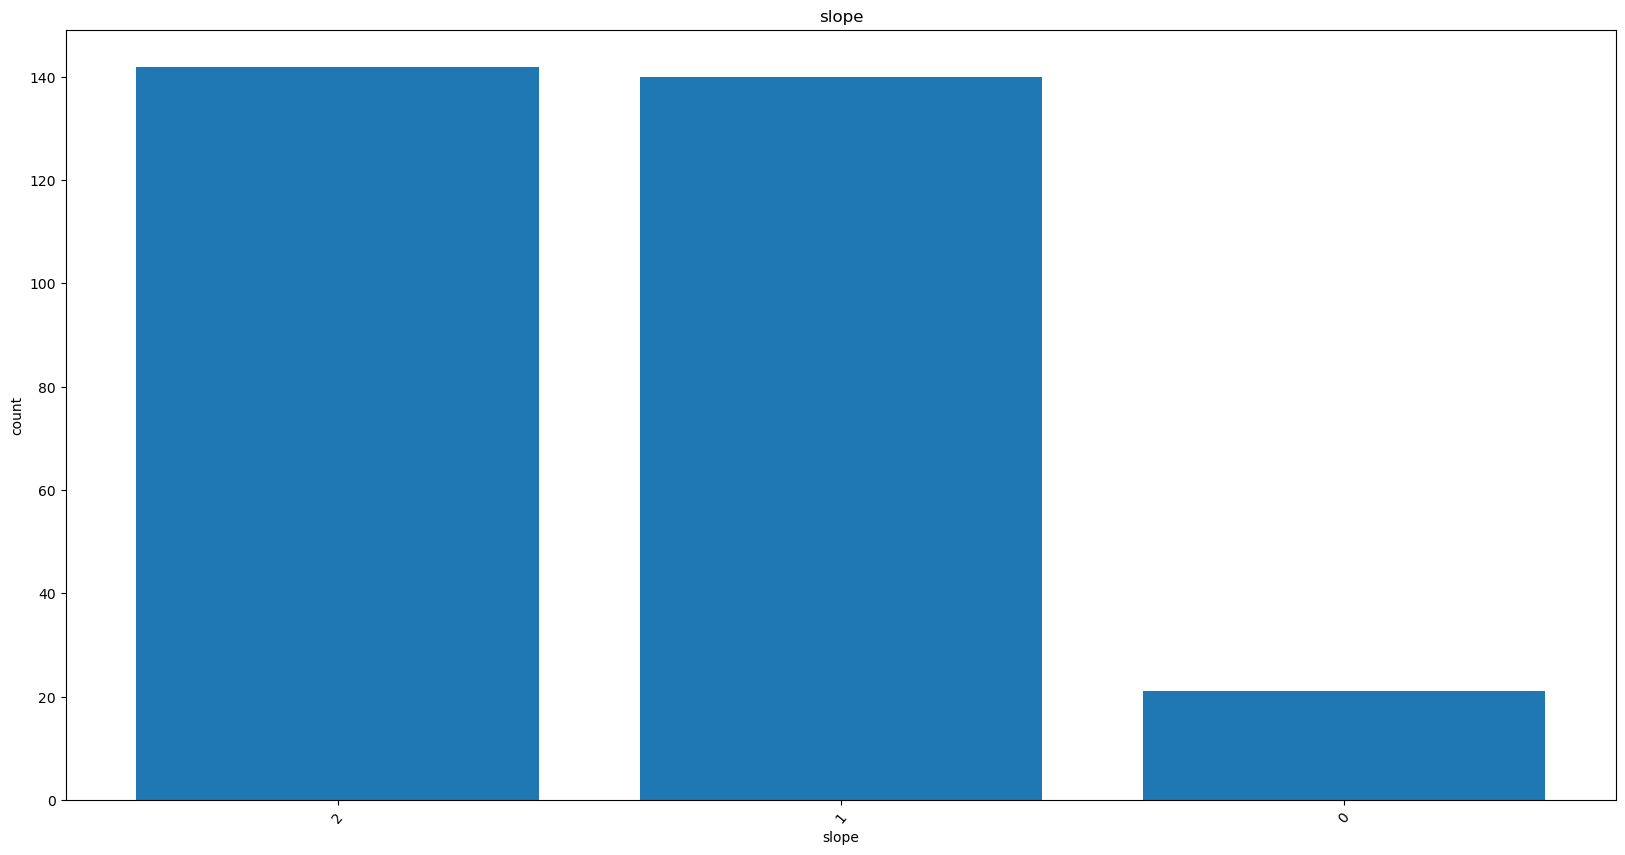

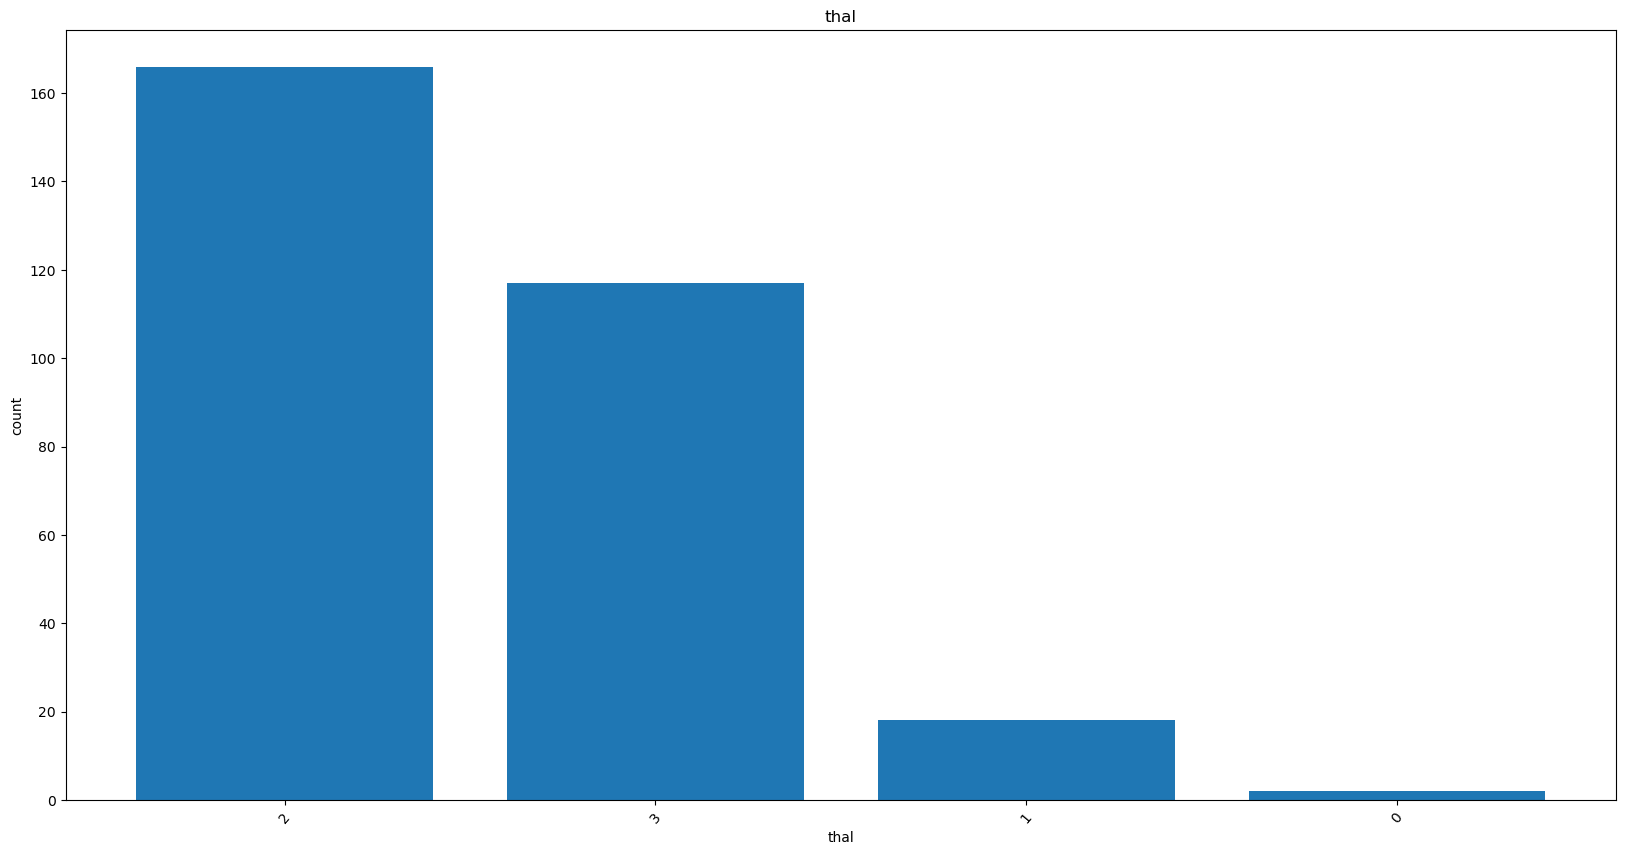

In [13]:
for col in kat:
    
    counts = df[col].value_counts()
    plt.figure(figsize = (20, 10))
    plt.bar(counts.index, counts.values)
    plt.xticks(rotation=50)
    plt.title(col)
    plt.xlabel(col)
    plt.ylabel("count")
    plt.show()

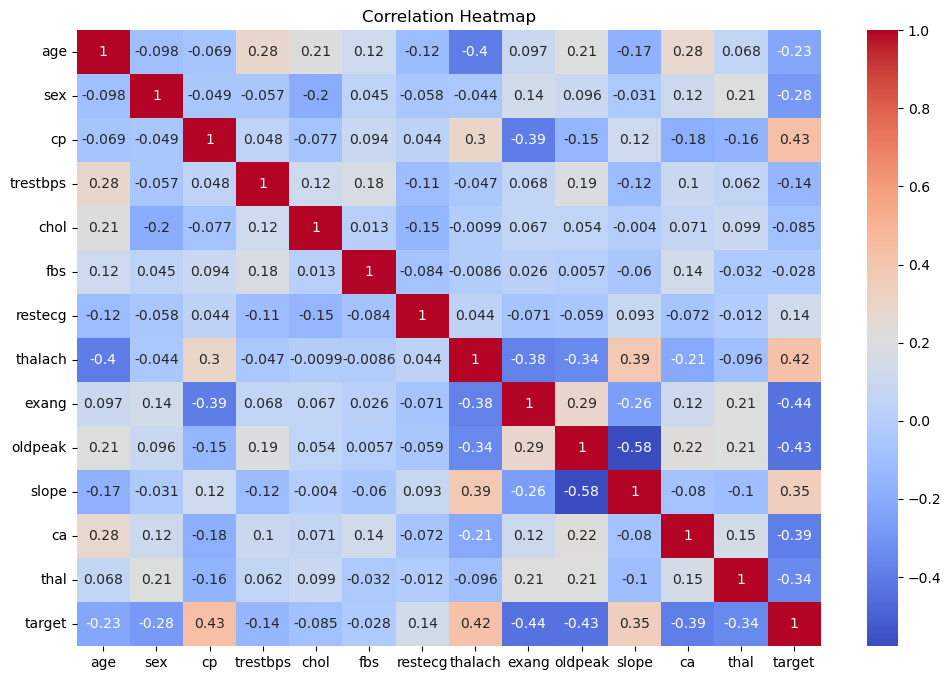

In [14]:
# Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Preprocessing

In [15]:
from sklearn.model_selection import train_test_split

X = df.drop("target", axis=1)
y = df["target"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [16]:
X_train[kat]=X_train[kat].astype(int)
X_test[kat]=X_test[kat].astype(int)

## Transforming

In [17]:
X_train["oldpeak"] = np.log1p(X_train["oldpeak"])
X_test["oldpeak"] = np.log1p(X_test["oldpeak"])

## Scaling

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train[numeric] = scaler.fit_transform(X_train[numeric])
X_test[numeric] = scaler.transform(X_test[numeric])

## Encoding

In [19]:
onehot_cols = ['cp','restecg','thal']

In [20]:
from sklearn.preprocessing import OneHotEncoder
onehot = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_enc = onehot.fit_transform(X_train[onehot_cols])
X_test_enc = onehot.transform(X_test[onehot_cols])

cols = onehot.get_feature_names_out(onehot_cols)

X_train = pd.concat(
    [X_train.drop(columns=onehot_cols),
     pd.DataFrame(X_train_enc, columns=cols, index=X_train.index)],
    axis=1)

X_test = pd.concat(
    [X_test.drop(columns=onehot_cols),
     pd.DataFrame(X_test_enc, columns=cols, index=X_test.index)],
    axis=1)

# Modelling

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve)

Model 1  (Logistic Regression)

In [22]:
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train, y_train)

y_pred_lr = model_lr.predict(X_test)
y_prob_lr = model_lr.predict_proba(X_test)[:, 1]

In [23]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print("ROC AUC:", roc_auc_score(y_test, y_prob_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.8360655737704918
ROC AUC: 0.8744588744588744
[[21  7]
 [ 3 30]]
              precision    recall  f1-score   support

           0       0.88      0.75      0.81        28
           1       0.81      0.91      0.86        33

    accuracy                           0.84        61
   macro avg       0.84      0.83      0.83        61
weighted avg       0.84      0.84      0.83        61



Model 2 (Random Forest)

In [24]:
model_rf = RandomForestClassifier(random_state=42)
model_rf.fit(X_train, y_train)

y_pred_rf = model_rf.predict(X_test)
y_prob_rf = model_rf.predict_proba(X_test)[:, 1]

In [25]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC AUC:", roc_auc_score(y_test, y_prob_rf))
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Accuracy: 0.7704918032786885
ROC AUC: 0.8787878787878788
[[18 10]
 [ 4 29]]
              precision    recall  f1-score   support

           0       0.82      0.64      0.72        28
           1       0.74      0.88      0.81        33

    accuracy                           0.77        61
   macro avg       0.78      0.76      0.76        61
weighted avg       0.78      0.77      0.77        61



Cross Validation

In [26]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model_rf,
    X,
    y,
    cv=5,
    scoring="roc_auc"
)

print("Cross Validation ROC-AUC:", cv_scores.mean())

Cross Validation ROC-AUC: 0.8984527817861151


## Hyperparameter Tuning (GridSearch)

Random forest gives better metrics, therefore random forest will be tuned

preprocessing steps such as scaling and transforming wont be used for random forest

In [27]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}

grid = GridSearchCV(
    RandomForestClassifier(criterion='entropy', random_state=42),
    param_grid,
    cv=5,
    scoring="roc_auc",
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

Best Parameters: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Score: 0.9216524216524217


Best Parameters: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Best CV Score: 0.9216524216524217

In [28]:
best_rf = grid.best_estimator_

y_pred_best = best_rf.predict(X_test)
y_prob_best = best_rf.predict_proba(X_test)[:, 1]

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, y_pred_best))
print("ROC AUC:", roc_auc_score(y_test, y_prob_best))
print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))

=== Tuned Random Forest ===
Accuracy: 0.819672131147541
ROC AUC: 0.9123376623376623
[[18 10]
 [ 1 32]]
              precision    recall  f1-score   support

           0       0.95      0.64      0.77        28
           1       0.76      0.97      0.85        33

    accuracy                           0.82        61
   macro avg       0.85      0.81      0.81        61
weighted avg       0.85      0.82      0.81        61



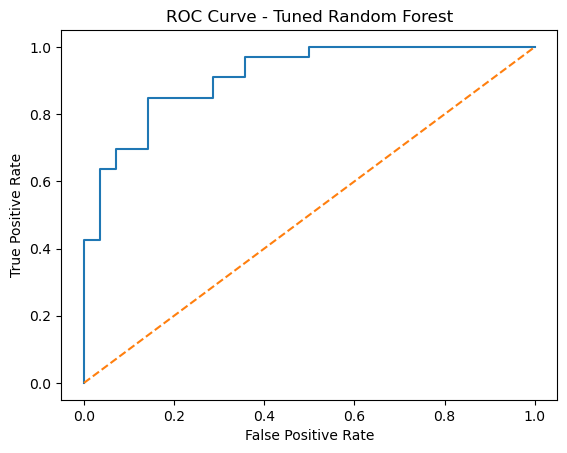

In [29]:
fpr, tpr, _ = roc_curve(y_test, y_prob_best)

plt.figure()
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Tuned Random Forest")
plt.show()